# Análisis semántico de la colección de proyectos

En este notebook se analiza la estructura semántica del corpus de proyectos previamente filtrados en el dominio aeroespacial.

Tras haber realizado un análisis exploratorio textual (longitud, densidad léxica y homogeneidad estructural), el siguiente paso consiste en evaluar la similitud semántica entre proyectos utilizando modelos de embeddings basados en transformers.

El objetivo es:
- Medir el grado de homogeneidad semántica del corpus.
- Detectar posibles subestructuras temáticas o clusters naturales.
- Identificar proyectos altamente similares o potencialmente duplicados.
- Evaluar el impacto del posible boilerplate institucional en la similitud global.

Para ello, se generan representaciones vectoriales de los textos y se calcula la similitud coseno proyecto–proyecto, permitiendo analizar la distribución de similitudes y la cohesión interna del dominio.

Este análisis es clave antes de proceder a la clasificación automática frente a la taxonomía PAE, ya que permite comprender la organización semántica real del corpus y anticipar posibles limitaciones del modelo.

El análisis nos demuestra que aunque hay cohesión semántica, todavía hay proyectos que no pertenecen al dominio aeroespacial. Al final del ntoebook, trataremos de descartar estos proyectos.


Secciones:

1️⃣ Generar embeddings
2️⃣ Similitud proyecto–proyecto
3️⃣ Distribución de similitudes
4️⃣ Detección de duplicados
5️⃣ Media de similitud por proyecto
6️⃣ PCA 2D
7️⃣ Clustering opcional

## 1. Cargar corpus

In [ ]:
# Necesario montar nuestra unidad de google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import pandas as pd

os.chdir("/content/drive/MyDrive/PROYECTOS/PAE")
print("DIRECTORIO DE TRABAJO:", os.getcwd())
#os.listdir()

INPUT_FILE = "data/EUproject_aerospatial_filtered_5000.csv"
# INPUT_FILE = "data/EUproject_aerospace_5000_refined_meanSim_ge_005.csv"


print("FICHERO DEL CORPUS:", os.getcwd())

df = pd.read_csv(INPUT_FILE, encoding="utf-8")

print("Shape:", df.shape)
# print("Columnas:", list(df.columns))

# borro la columna Nivel_1 que ya no nos aporta nada
if "Nivel_1" in list(df.columns):
    df.drop(columns=["Nivel_1"], inplace=True)
print("Columnas:", list(df.columns))

df.head(2)


DIRECTORIO DE TRABAJO: /content/drive/MyDrive/PROYECTOS/PAE
FICHERO DEL CORPUS: /content/drive/MyDrive/PROYECTOS/PAE
Shape: (5374, 4)
Columnas: ['title', 'description', 'text']


,title,description,text
0,Tilt Rotor ATM Integrated Validation of Enviro...,"""Cleansky-Green Rotor Craft sub-project 5 is a...",Tilt Rotor ATM Integrated Validation of Enviro...
1,Prefabricated CFRP Parts,Due to the increasing use of carbon fibre rein...,Prefabricated CFRP Parts. Due to the increasin...


## 2. Generación de embeddings

Se puede ejecutar sin GPU.

Sin embargo, es recomendable que tengas activado GPU para una ejecución más rápida.

Si estás en Google Colab:
Entorno de ejecución -> Cambiar tipo de entorno de ejecución -> seleccionar GPU T4. Reinicias y vuelves a ejecutar desde el principio.

La siguiente celda carga un módelo de sentence embedding, que nos permite transformar cada proyecto en un vector semántico.



In [ ]:
# Si en tu entorno no está instalado.
# !pip -q install sentence-transformers

from sentence_transformers import SentenceTransformer
import numpy as np

MODEL_NAME = "sentence-transformers/all-mpnet-base-v2"

model = SentenceTransformer(MODEL_NAME)

texts = df["text"].astype(str).tolist()

embeddings = model.encode(
    texts,
    normalize_embeddings=True,
    batch_size=64,
    show_progress_bar=True
)

print("Shape embeddings:", embeddings.shape)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/84 [00:00<?, ?it/s]

Shape embeddings: (5374, 768)


El siguiente paso es construir la matriz que calcula la similitud (basada en la distancia del coseno) proyecto-proyecto.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
S = cosine_similarity(embeddings)
print("Shape matriz similitud:", S.shape)

Shape matriz similitud: (5374, 5374)


La diagonal principal de la matriz de similitud contiene exclusivamente valores iguales a 1, ya que cada elemento diagonal corresponde a la similitud coseno de un proyecto consigo mismo. Al trabajar con embeddings normalizados, esta similitud es, por definición, máxima.

Nota: Los valores de la diagonal no son exactamente 1 debido a errores de precisión numérica asociados al uso de números en coma flotante (float32). Durante el cálculo del producto punto y la normalización de los embeddings se producen pequeños redondeos, lo que puede generar desviaciones mínimas respecto a 1 (por ejemplo, 0.9999999 o 1.0000004). Estas diferencias son insignificantes y completamente normales en cálculos numéricos.



In [ ]:
import numpy as np
np.diag(S)

array([1.        , 1.0000005 , 0.99999994, ..., 1.0000004 , 1.0000004 ,
       1.0000001 ], dtype=float32)

Puedo forzar a qué todo sea 1.0

In [ ]:
np.fill_diagonal(S, 1.0)
np.diag(S)

array([1., 1., 1., ..., 1., 1., 1.], dtype=float32)

Calculamos también la media de similitud que tiene cada proyecto:

In [ ]:
n = S.shape[0]  # número de proyectos

# La siguiente línea cálcula la similitud de cada proyecto (fila) con el resto.
# S.sum(axis=1) - 1: sumo cada fila, y le resto 1 (que es la similitud del proyecto consigo misma)
# luego divido por el número de proyectos, que es n-1
mean_sim = (S.sum(axis=1) - 1) / (n - 1)
df["mean_sim_to_others"] = mean_sim
df["mean_sim_to_others"].describe(percentiles=[0.05,0.1,0.25,0.5,0.75,0.9,0.95])


,mean_sim_to_others
count,5374.000000
mean,0.173973
std,0.062347
min,-0.037172
5%,0.046561
10%,0.078945
25%,0.137726
50%,0.187868
75%,0.217956
90%,0.242761




El nivel medio de similitud es relativamente bajo (0.17) y muy similar a la mediana (0.18).
Esto se puede interpretar como:
* El corpus NO es excesivamente homogéneo semánticamente.
* Hay diferenciación temática real
* El boilerplate no domina semánticamente. Es decir, si hay repeticiones de patrones de texto, no están influyendo en la semántica del texto.

Respecto al IQR (Q3-Q1) si es pequeño, muestra que el corpus es más homogéneo, pero si fuera grande, mostraría que hay una mayor dispersión temática. Nuestro IQR (Q3-Q1 = 0.218-0.138) muestra que el 50% central del corpus está en un rango relativamente estrecho (~0.08 de amplitud). Esto significa que hay cohesión temática general, pero también gradiente de especialización


El mínimo es negativo!!!. Cosine similarity puede ser negativa cuando dos vectores apuntan en direcciones opuestas. Es decir, hay algunos proyectos bastante alejados del centro semántico. Podrían pertenecer a subdominios muy específicos. O estar mal alineados con el resto del corpus (podrían no ser del dominio aeroespacial). Conviene inspeccionar los 5 más bajos.

Respecto al máximo (0.31), no es extremadamente alto.
Significa que incluso los proyectos más “centrales”, no son extremadamente parecidos al resto.

Esto sugiere:
* Buena diversidad interna
* No hay dominancia de un único tema
* No hay duplicación masiva


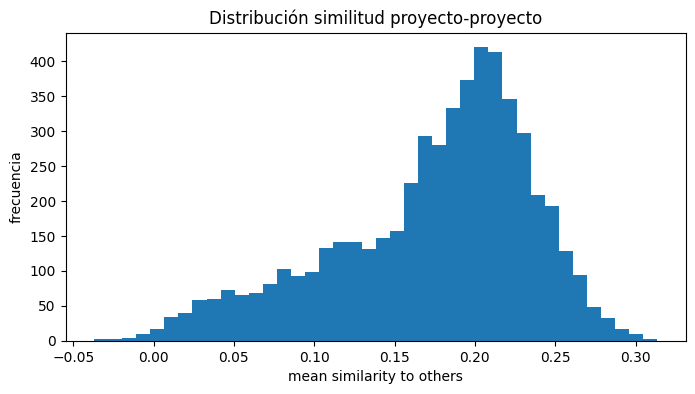

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(df["mean_sim_to_others"], bins=40)
plt.title("Distribución similitud proyecto-proyecto")
plt.xlabel("mean similarity to others")
plt.ylabel("frecuencia")
plt.show()

El histograma nos proporciona información similar y complementaria a la de las estadísticas.

Observamos:
* Distribución claramente unimodal.
* Pico principal alrededor de 0.19–0.22.
* Cola izquierda extendida hacia valores bajos (incluso negativos).
* Cola derecha más corta, hasta ~0.31.

Esto sugiere:

* Un núcleo semántico relativamente compacto
* Variabilidad temática real
* No hay multimodalidad clara (no se ven picos separados)
* La mayoría de los proyectos tienen una similitud media moderada con el resto del corpus. Esto indica comparten dominio general (ingeniería/aeroespacial), pero no son extremadamente redundantes

La forma suavemente asimétrica sugiere:

* Hay un núcleo central de proyectos representativos.
* Hay un gradiente continuo hacia mayor especialización.
*  No se observan clusters completamente separados.

Eso es coherente con un dominio amplio (ingeniería/aeroespacial) con subtemas conectados.

## Conclusiones

Tu corpus es:

* Cohesionado temáticamente
* No redundante
* No excesivamente homogéneo
* Con subestructuras reales

El valor medio 0.17 indica que los proyectos comparten un dominio común (ingeniería/aeroespacial), pero presentan suficiente diversidad temática como para permitir discriminación semántica.


Esto es ideal para:
* Clasificación contra taxonomía PAE
* Zero-shot semantic matching
* Clustering

Un corpus problemático mostraría:
* Media > 0.35 → demasiado homogéneo.
* Distribución extremadamente estrecha. Pico muy alto y concentrado.
* Cola derecha muy larga (>0.5).


## Filtramos los proyectos que no son del dominio aeroespacial

Para ello vamos a comenzar analizando el 15% más bajos (con menor similitud) y los 10% más altos (con mayor similitud)



In [ ]:
p15 = df["mean_sim_to_others"].quantile(0.15)
p90 = df["mean_sim_to_others"].quantile(0.90)

print("Percentil 15:", p15)
print("Percentil 90:", p90)

df_low = df[df["mean_sim_to_others"] <= p15].copy()
df_high = df[df["mean_sim_to_others"] >= p90].copy()

print("Nº proyectos 15% más bajos:", len(df_low))
print("Nº proyectos 90% más altos:", len(df_high))

Percentil 15: 0.1029137436300516
Percentil 90: 0.2427612394094467
Nº proyectos 15% más bajos: 806
Nº proyectos 90% más altos: 538


Mostramos los títulos de los más específicos. Se los voy a pasar a chatgpt para que me digan si hay alguno del dominio aeroespacial

In [ ]:
subset = df_low.sort_values("mean_sim_to_others", ascending=False).head(10)

for i, row in subset.iterrows():
    print("="*120)
    print(f"Similitud media: {row['mean_sim_to_others']:.4f}")
    print(f"TÍTULO:\t{row['title']}")
    #print(f"nTEXTO:\t{row['text']}")
    #print("\n")


Similitud media: 0.1027
TÍTULO:	Regional phytoplankton ecophysiology products for coastal waters from local and satellite measurements
Similitud media: 0.1027
TÍTULO:	Compressed and Deep Sensing: Models, Structures, and Tasks
Similitud media: 0.1023
TÍTULO:	Hot-spots of Phosphorus and Nitrogen delivery in Time and Space in agricultural catchments
Similitud media: 0.1022
TÍTULO:	Dynamics of Earth’s core from multi-satellite observations
Similitud media: 0.1022
TÍTULO:	SPATIAL TEMPORAL PATTERNS FOR ACTION-ORIENTED PERCEPTION IN ROVING ROBOTS II: AN INSECT BRAIN COMPUTATIONAL MODEL
Similitud media: 0.1020
TÍTULO:	Graphene-based flexible perovskite solar cells for space applications
Similitud media: 0.1020
TÍTULO:	Smart Coordination Polymers with Compartmentalized Pockets for Adaptive Guest Entrance
Similitud media: 0.1020
TÍTULO:	CONFINED CATALYSIS IN LAYERED MATERIALS – A TRANSFORMATIONAL APPROACH FOR EFFICIENT WATER SPLITTING
Similitud media: 0.1020
TÍTULO:	Metal-Piezoelectric-Insulator

Chatgpt nos dice que de los proyectos mostrados:
- 1 claramente
- 1 parcialmente
- 8 no


Veamos ahora los proyectos que tienen más similitud con otros:

In [ ]:
subset = df_high.sort_values("mean_sim_to_others", ascending=False).head(5)
for i, row in subset.iterrows():
    print("="*120)
    print(f"Similitud media: {row['mean_sim_to_others']:.4f}")
    print(f"TÍTULO:\t{row['title']}")
    #print(f"nTEXTO:\t{row['text']}")
    #print("\n")

Similitud media: 0.3137
TÍTULO:	NEXTAIR - multi-disciplinary digital - enablers for NEXT-generation AIRcraft design and operations
Similitud media: 0.3052
TÍTULO:	The systematic Integration of Novel Aerospace Technologies
Similitud media: 0.3047
TÍTULO:	Collaborative System of Systems Exploration of Aviation Products, Services and Business Models
Similitud media: 0.3038
TÍTULO:	GReener Aeronautics International Networking-2
Similitud media: 0.3027
TÍTULO:	SYSTEMS ITD GAM 2020
Similitud media: 0.3022
TÍTULO:	European iNitiative for Low cost, Innovative & Green High Thrust ENgine
Similitud media: 0.3003
TÍTULO:	Development of an Advanced Software Tool for Aircraft-level Investigation of the Impact of new Architectures for Avionics and On-board General Systems for the Green Regional Aircraft
Similitud media: 0.2998
TÍTULO:	Coordination Action Pro “Production, Avionics, Design” on Cost-efficiency in Aeronautics
Similitud media: 0.2998
TÍTULO:	JTI-Clean Sky 1-Technology Evaluator
Similitud 

Sin embargo, estos proyectos si que son claramente del dominio aeroespacial.  Todos contienen términos claramente aeroespaciales: aircraft, aerodynamic, etc.


### Filtrando usando un umbral
Podríamos filtrarlos, simplemente quedándonos únicamente con los proyectos que tienen una similitud media > que un determinado umbral (por ejemplo, 0.11, viendo lo observado en las celdas anteriores).

Sin embargo, aunque es la forma más sencilla de implementar, no es la opción recomendable, porque aún así todavía habría muchos proyectos que no son del dominio.


In [ ]:
THRESH_MEAN_SIM = 0.11

df_refined = df[df["mean_sim_to_others"] >= THRESH_MEAN_SIM].copy()

print("Umbral:", THRESH_MEAN_SIM)
print("Antes:", len(df))
print("Después:", len(df_refined))
print("Eliminados:", len(df) - len(df_refined))

from google.colab import files

OUT_FILE = "data/EUproject_aerospace_5000_refined_meanSim_ge_011.csv"
df_refined.to_csv(OUT_FILE, index=False, encoding="utf-8-sig")

print("Guardado:", OUT_FILE)

Umbral: 0.11
Antes: 5374
Después: 4468
Eliminados: 906
Guardado: data/EUproject_aerospace_5000_refined_meanSim_ge_011.csv


### Filtrado usando embeddings


En su lugar, vamos a

* Tomamos el top 10% con mayor mean_sim_to_others.
* Calculamos su embedding promedio (lo llamaremos **aero_center**).
* Calculamos la similitud de cada proyecto a este aero_center, y lo almacenamos en **sim_to_aero_center**.
** Ahroa sí usaremos esa nueva métrica para filtrar.


In [ ]:
import numpy as np

TOP_FRAC = 0.10
top_n = int(len(df) * TOP_FRAC)

top_idx = df["mean_sim_to_others"].sort_values(ascending=False).head(top_n).index.to_numpy()

aero_center = embeddings[top_idx].mean(axis=0)
aero_center = aero_center / np.linalg.norm(aero_center)

print("Top_n:", top_n)
print("Center norm:", np.linalg.norm(aero_center))

# 2) Similaridad de cada proyecto contra el centro
import numpy as np

# 1) Construir centro a partir del top 10% más central
TOP_FRAC = 0.10
top_n = int(len(df) * TOP_FRAC)

top_idx = df["mean_sim_to_others"].sort_values(ascending=False).head(top_n).index.to_numpy()

aero_center = embeddings[top_idx].mean(axis=0)
aero_center = aero_center / np.linalg.norm(aero_center)

print("Top_n:", top_n)
print("Center norm:", np.linalg.norm(aero_center))

# 2) Similaridad de cada proyecto contra el centro
df["sim_to_aero_center"] = embeddings @ aero_center

# 3) Inspeccionar distribución para decidir umbral
print(df["sim_to_aero_center"].describe(percentiles=[0.01,0.05,0.1,0.25,0.5,0.75,0.9,0.95,0.99]))

# 4) Filtrado por percentil (ej: quedarte con top 30% más aero)
KEEP_TOP = 0.30
thr = float(df["sim_to_aero_center"].quantile(1 - KEEP_TOP))

df_aero = df[df["sim_to_aero_center"] >= thr].copy()

print("Umbral:", thr)
print("Antes:", len(df), "Después:", len(df_aero))

# 3) Inspeccionar distribución para decidir umbral
print(df["sim_to_aero_center"].describe(percentiles=[0.01,0.05,0.1,0.25,0.5,0.75,0.9,0.95,0.99]))

# 4) Filtrado por percentil (ej: quedarte con top 30% más aero)
# KEEP_TOP = 0.30
# thr = float(df["sim_to_aero_center"].quantile(1 - KEEP_TOP))




Top_n: 537
Center norm: 1.0
Top_n: 537
Center norm: 1.0
count    5374.000000
mean        0.397717
std         0.181423
min        -0.123121
1%         -0.029573
5%          0.050137
10%         0.124864
25%         0.280271
50%         0.431052
75%         0.527686
90%         0.607063
95%         0.655648
99%         0.727561
max         0.800323
Name: sim_to_aero_center, dtype: float64
Umbral: 0.5079212009906768
Antes: 5374 Después: 1612
count    5374.000000
mean        0.397717
std         0.181423
min        -0.123121
1%         -0.029573
5%          0.050137
10%         0.124864
25%         0.280271
50%         0.431052
75%         0.527686
90%         0.607063
95%         0.655648
99%         0.727561
max         0.800323
Name: sim_to_aero_center, dtype: float64


Fíjate:

* P10 = 0.125
* P25 = 0.280
* Mediana = 0.431

Eso significa que:
* El 75% del corpus tiene similitud > 0.28
* El 50% tiene > 0.43

Esto sugiere que el dominio aeroespacial es dominante.

Si elegimos Umbral ≈ 0.30
* Esto elimina todo el 25% inferior.
* Te quedarías con ≈ 75% del corpus.
* Muy pocos fuera de dominio.

Si elegimos Umbral ≈ 0.25
- Mantienes ~75–80% del corpus.
- Probablemente conserva: Space weather, Satellite systems, Communications, Materiales para espacio
- Elimina: Ciencias sociales, Bioingeniería, Física cuántica pura

Si elegimos Umbral  ≈ 0.45
- Mantienes solo la mitad superior.
- Esto te deja con: Aircraft, Avionics, Engines, Clean Sky, Aviation systems.

La recomendación de chatgpto es 0.28. Pero mirando las oraciones hay muchas fuera del dominio.

Probamos con 0.35 (sigue siendo demasiado bajo)

probamos con 0.45



In [ ]:
thr = 0.45
df_aero = df[df["sim_to_aero_center"] >= thr].copy()

print("Umbral:", thr)
print("Antes:", len(df), "Después:", len(df_aero))

subset = df_aero.sort_values("sim_to_aero_center", ascending=True).head(10)

for i, row in subset.iterrows():
    print("="*120)
    print(f"Similitud media: {row['sim_to_aero_center']:.4f}")
    print(f"TÍTULO:\t{row['title']}")
    #print(row["text"][:1000])  # primeros 1000 caracteres
    #print("\nTEXTO:\n")
    #print(row["text"])
    #print("\n")

Umbral: 0.45
Antes: 5374 Después: 2456
Similitud media: 0.4501
TÍTULO:	RESilient transport InfraSTructure to extreme events
Similitud media: 0.4501
TÍTULO:	SPAce-CompatiblE- Filters_in_dIelectric waveguide Technology
Similitud media: 0.4501
TÍTULO:	Solar Thermochemical Compact Storage System
Similitud media: 0.4501
TÍTULO:	Engine and turbine combustion of bioliquids for combined heat and power production
Similitud media: 0.4501
TÍTULO:	Making Wind Energy More Profitable...Faster!
Similitud media: 0.4501
TÍTULO:	Macro, Micro and Nano Aspects of Machining
Similitud media: 0.4501
TÍTULO:	European Networking for satellite Telecommunication Roadmap for the governmental Users requiring Secure, inTeroperable, InnovativE and standardiseD services
Similitud media: 0.4501
TÍTULO:	Space-based maritime navigation
Similitud media: 0.4502
TÍTULO:	Developing the Next Generation of Environmentally-Friendly Floating Wind Farms with Innovative Technologies and Sustainable Solutions
Similitud media: 0.45

Estoy probando distintos umbrales, incluso altos, pero no hay manra de obt3ener solo proyectos aeroespaciales.

Porque estamos usando:
Centro = media de embeddings del top 10% con mayor mean_sim_to_others



## Filtrando usando el centro de embeddings de categorías PAE.


Vamos usar Centro = embeddings de categorías PAE pero solo las claramente aeroespaciales.

No todas.

Eso elimina la contaminación de ingeniería general.

In [ ]:
FILE_TAX = "data/aerotax_transformado.csv"
df_tax = pd.read_csv(FILE_TAX, encoding="utf-8")
print("Shape:", df_tax.shape)
df_tax.head(3)

texts_tax = df_tax["text"].astype(str).tolist()

embeddings_tax = model.encode(
    texts_tax,
    normalize_embeddings=True,
    batch_size=64,
    show_progress_bar=True
)

print("Shape embeddings de la taxonomía:", embeddings_tax.shape)

Shape: (151, 4)


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Shape embeddings de la taxonomía: (151, 768)


In [ ]:
# Centro (media) + normalización
pae_center = embeddings_tax.mean(axis=0)
pae_center = pae_center / np.linalg.norm(pae_center)

print("Centro PAE shape:", pae_center.shape)
print("Norma del centro:", np.linalg.norm(pae_center))

Centro PAE shape: (768,)
Norma del centro: 0.99999994


In [ ]:
df_tax["sim_to_pae_center"] = embeddings_tax @ pae_center
df_tax.sort_values("sim_to_pae_center", ascending=False).head(10)[
    ["category_code", "category_label", "sim_to_pae_center"]
]

,category_code,category_label,sim_to_pae_center
73,1E0,Flight Mechanics,0.788331
61,1D0,"Aircraft Avionics, Systems & Equipments",0.787014
101,1F0,Integrated Design & Validation (methods & tools),0.785434
59,1D1,Avionics,0.776428
74,1E5,System Failure and Damage Analysis,0.755277
82,1F22,Development of operational research methods & ...,0.743354
49,1D21,Environmental control System,0.735443
36,1C0,Propulsion & Power,0.728225
115,1G7,ATM automated support,0.728027
60,1D4,Warning System,0.727172


In [ ]:
# 2) Similaridad de cada proyecto contra el centro
df["sim_to_tax_center"] = embeddings @ pae_center
# 3) Inspeccionar distribución para decidir umbral
print(df["sim_to_tax_center"].describe(percentiles=[0.01,0.05,0.1,0.25,0.5,0.75,0.9,0.95,0.99]))



count    5374.000000
mean        0.311920
std         0.169198
min        -0.155678
1%         -0.087045
5%         -0.003365
10%         0.068080
25%         0.199439
50%         0.326669
75%         0.443043
90%         0.521024
95%         0.560274
99%         0.619761
max         0.717123
Name: sim_to_tax_center, dtype: float64


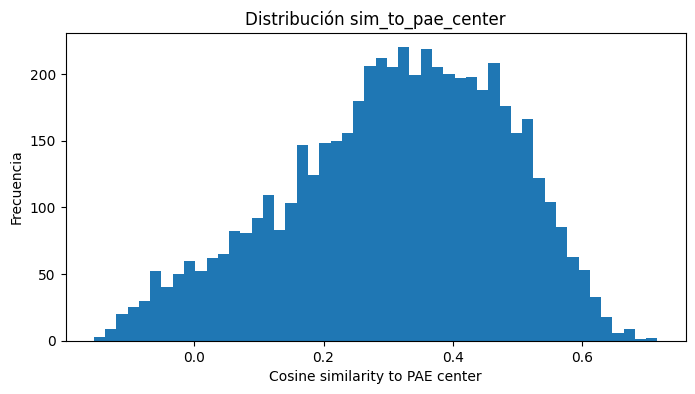

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(df["sim_to_tax_center"], bins=50)
plt.title("Distribución sim_to_pae_center")
plt.xlabel("Cosine similarity to PAE center")
plt.ylabel("Frecuencia")
plt.show()

Mirando el histograma podemos observar

* Distribución unimodal
* Pico principal alrededor de 0.35 – 0.45
* Cola izquierda que baja hasta valores negativos
* Cola derecha que llega aproximadamente a 0.65–0.70
* No hay dos picos claramente separados. Eso significa que no hay una separación natural tipo “gap” limpio.

Por tanto:

* El umbral no va a salir solo visualmente.
* Hay que elegirlo estratégicamente.

Visualmente se distinguen 4 regiones:

🔴 Región A: < 0.10

Muy pocos proyectos
Claramente fuera de dominio

🟠 Región B: 0.10 – 0.25

Zona creciente
Probablemente mezcla de: Ingeniería general, Space-enabled, Ciencia aplicada

🟡 Región C: 0.25 – 0.45:

* Masa principal.
* Zona de transición
* Aquí hay mezcla real

🟢 Región D: > 0.45

Zona claramente alineada con PAE
Cola derecha más “pura”


In [ ]:
# Filtrado por umbral
thr = 0.45
df_aero = df[df["sim_to_tax_center"] >= thr].copy()

print("Umbral:", thr)
print("Antes:", len(df), "Después:", len(df_aero))


subset = df_aero.sort_values("sim_to_tax_center", ascending=True).head(10)

for i, row in subset.iterrows():
    print("="*120)
    print(f"Similitud media: {row['sim_to_aero_center']:.4f}")
    print(f"TÍTULO:\t{row['title']}")


Umbral: 0.45
Antes: 5374 Después: 1255
Similitud media: 0.4870
TÍTULO:	Fuel Injector Research for Sustainable Transport
Similitud media: 0.4652
TÍTULO:	Advanced Methods in Building Diagnostics and Maintenance
Similitud media: 0.5347
TÍTULO:	HydrogEn combuSTion In Aero engines
Similitud media: 0.5236
TÍTULO:	Integrated Intelligent Bearing Systems for UHPE Ground Test Demo (I2BS)
Similitud media: 0.5494
TÍTULO:	Integration of Innovative Ice Protection Systems
Similitud media: 0.5006
TÍTULO:	A handheld, ultra-sensitive device for rapid contactless explosive vapour detection in open air, based on Ion Mobility Universal Sensor Technology
Similitud media: 0.3974
TÍTULO:	Advanced DCB
Similitud media: 0.5921
TÍTULO:	Ship performance monitoring and simulation to reduce fuel consumption and emissions.
Similitud media: 0.4640
TÍTULO:	Cognitive Collaboration for Teaming
Similitud media: 0.4724
TÍTULO:	Concept, design and prototyping of compact sensor nodes using electromechanical impedance and bro

Le pasamos eso proyectos a chatgpt, y nos dice:
